In [1]:
import anndata as ad

In [2]:
import pandas as pd
import scipy.sparse as sp

In [3]:
from tqdm import tqdm

In [4]:
from genome_tools.data.anndata import read_zarr_backed
from genome_tools.data.extractors import FastaExtractor, TabixExtractor
from collections import defaultdict


In [5]:
import numpy as np

In [6]:
import anndata as ad
import pandas as pd
import numpy as np
import warnings
from tqdm import tqdm

from genome_tools import GenomicInterval, VariantInterval

In [7]:
from collections import defaultdict


In [8]:
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')
# adata

/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings

In [14]:
non_aggregated_variants = pd.read_parquet('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/output/non_aggregated.all.parquet')

In [15]:
# non_aggregated_variants = pd.read_parquet('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/output/non_aggregated.all.parquet')
non_aggregated_variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,logit_es,pval_ref,pval_alt,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id
0,chr1,792967,792968,rs374690515,C,G,10,4,AG92962,0.000279,...,0.817893,0.258132,0.885408,0.516265,NaN,0,-,0,7.971374,all
1,chr1,794251,794252,rs116720794,C,T,3,7,AG92839,0.035160,...,-0.816932,0.858276,0.328257,0.656514,NaN,0,-,0,7.145565,all
2,chr1,794298,794299,rs4951859,C,G,4,6,AG92839,0.667264,...,-0.354383,0.718494,0.489453,0.978905,NaN,0,-,0,7.145565,all
3,chr1,794298,794299,rs4951859,C,G,4,6,AG92853,0.667264,...,-0.575720,0.828125,0.376953,0.753906,NaN,0,-,0,7.784989,all
4,chr1,794298,794299,rs4951859,C,G,5,5,AG80066,0.667264,...,0.000000,0.623047,0.623047,1.000000,NaN,0,-,0,7.784989,all
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48190820,chr9,138219528,138219529,rs11791069,T,A,8,5,AG92871,0.239058,...,0.667261,0.290527,0.866577,0.581055,NaN,0,-,0,8.876254,all
48190821,chr9,138219528,138219529,rs11791069,T,A,9,2,AG80048,0.239058,...,2.122939,0.032715,0.994141,0.065430,NaN,0,-,0,8.164966,all
48190822,chr9,138219528,138219529,rs11791069,T,A,9,3,AG70816,0.239058,...,1.075964,0.208383,0.923064,0.416767,NaN,0,-,0,7.609493,all
48190823,chr9,138220931,138220932,rs184927972,C,A,3,7,AG95599,0.080546,...,-1.201315,0.945312,0.171875,0.343750,NaN,0,-,0,7.784989,all


In [11]:
non_aggregated_variants.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'group_id'],
      dtype='object')

In [12]:
non_aggregated_variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,logit_es,pval_ref,pval_alt,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id
0,chr1,792967,792968,rs374690515,C,G,10,4,AG92962,0.000279,...,0.817893,0.258132,0.885408,0.516265,NaN,0,-,0,7.971374,all
1,chr1,794251,794252,rs116720794,C,T,3,7,AG92839,0.035160,...,-0.816932,0.858276,0.328257,0.656514,NaN,0,-,0,7.145565,all
2,chr1,794298,794299,rs4951859,C,G,4,6,AG92839,0.667264,...,-0.354383,0.718494,0.489453,0.978905,NaN,0,-,0,7.145565,all
3,chr1,794298,794299,rs4951859,C,G,4,6,AG92853,0.667264,...,-0.575720,0.828125,0.376953,0.753906,NaN,0,-,0,7.784989,all
4,chr1,794298,794299,rs4951859,C,G,5,5,AG80066,0.667264,...,0.000000,0.623047,0.623047,1.000000,NaN,0,-,0,7.784989,all
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48190820,chr9,138219528,138219529,rs11791069,T,A,8,5,AG92871,0.239058,...,0.667261,0.290527,0.866577,0.581055,NaN,0,-,0,8.876254,all
48190821,chr9,138219528,138219529,rs11791069,T,A,9,2,AG80048,0.239058,...,2.122939,0.032715,0.994141,0.065430,NaN,0,-,0,8.164966,all
48190822,chr9,138219528,138219529,rs11791069,T,A,9,3,AG70816,0.239058,...,1.075964,0.208383,0.923064,0.416767,NaN,0,-,0,7.609493,all
48190823,chr9,138220931,138220932,rs184927972,C,A,3,7,AG95599,0.080546,...,-1.201315,0.945312,0.171875,0.343750,NaN,0,-,0,7.784989,all


In [13]:
import pysam
from collections import defaultdict
from tqdm import tqdm

genotype_file = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz"

tbx = pysam.TabixFile(genotype_file)

gt_map = defaultdict(set)

for chrom in tqdm(tbx.contigs, desc="Processing Chromosomes"):
    for line in tbx.fetch(chrom):
        fields = line.rstrip().split("\t")

        chrom = fields[0]
        start = int(fields[1])
        indiv_id = fields[5]
        gt = fields[6]

        key = (chrom, start, indiv_id)
        gt_map[key].add(gt)


Processing Chromosomes: 100%|██████████| 23/23 [06:23<00:00, 16.66s/it]


In [14]:
import pandas as pd
ambiguous_df = pd.DataFrame(
    [(c, s, i) for (c, s, i), gts in gt_map.items() if len(gts) > 1],
    columns=["#chr", "start", "indiv_id"],
)

print(f"Ambiguous genotype sites: {len(ambiguous_df)}")


Ambiguous genotype sites: 6799


In [17]:
ambiguous_df.to_parquet(
    "/home/mbrannon/tmp/ambiguous_sites.parquet",
    index=False
)


In [12]:
import pandas as pd

ambiguous_df = pd.read_parquet("/home/mbrannon/tmp/ambiguous_sites.parquet")
print(f"Loaded ambiguous sites: {len(ambiguous_df)} rows")


Loaded ambiguous sites: 6799 rows


In [16]:
non_aggregated_variants['variant_id'] = non_aggregated_variants['#chr'] + ":" + non_aggregated_variants['end'].astype(str) + ':' + non_aggregated_variants['ref'] + ':' + non_aggregated_variants['alt']
non_aggregated_variants['total_counts'] = non_aggregated_variants['ref_counts'] + non_aggregated_variants['alt_counts']

In [17]:
variants = non_aggregated_variants.query('coverage >= 35')

In [18]:
variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,pval_alt,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id,variant_id,total_counts
23,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,0.844748,0.499560,0.937686,0,-,0,14.564382,all,chr1:804904:C:T,35
65,chr1,817185,817186,rs3094315,G,A,23,13,AG80733,0.706382,...,0.742928,0.754975,1.000000,0,-,0,9.451293,all,chr1:817186:G:A,36
66,chr1,817185,817186,rs3094315,G,A,26,29,AG80823,0.706382,...,0.696446,0.706269,0.971396,0,-,0,9.795636,all,chr1:817186:G:A,55
69,chr1,817185,817186,rs3094315,G,A,33,24,AG70842,0.706382,...,0.436236,0.872472,0.891271,0,-,0,9.818754,all,chr1:817186:G:A,57
71,chr1,817185,817186,rs3094315,G,A,43,36,AG80260,0.706382,...,0.229725,0.459450,0.937870,0,-,0,9.996950,all,chr1:817186:G:A,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48190720,chr9,138217445,138217446,rs11562371,C,T,19,21,AG80066,0.370349,...,0.437315,0.874629,1.000000,0,-,0,15.569979,all,chr9:138217446:C:T,40
48190724,chr9,138217445,138217446,rs11562371,C,T,21,24,AG96533,0.370349,...,0.671661,0.788662,1.000000,0,-,0,9.649918,all,chr9:138217446:C:T,45
48190725,chr9,138217445,138217446,rs11562371,C,T,22,29,AG80065,0.370349,...,0.200531,0.401062,1.000000,0,-,0,17.580981,all,chr9:138217446:C:T,51
48190727,chr9,138217445,138217446,rs11562371,C,T,26,13,AG80357,0.370349,...,0.845422,0.494174,1.000000,0,-,0,9.527468,all,chr9:138217446:C:T,39


In [19]:
passed_read_count = (variants.total_counts > 20) & (variants.ref_counts > 0) & (variants.alt_counts > 0)
signif = (variants.FDR_sample < 0.1) & (variants.logit_es.abs() < 6)
neg = variants.FDR_sample > 0.5

positives = variants[passed_read_count & signif]
negatives = variants[passed_read_count & neg].sample(n=len(positives))

examples = pd.concat([positives, negatives])
#this doesnt work because its the genotype that has duplicates
examples = examples.groupby(["#chr", "start", "ref", "sample_id"]).filter(lambda x: len(x)==1)

Text(0.5, 0, 'LFC variant effect')

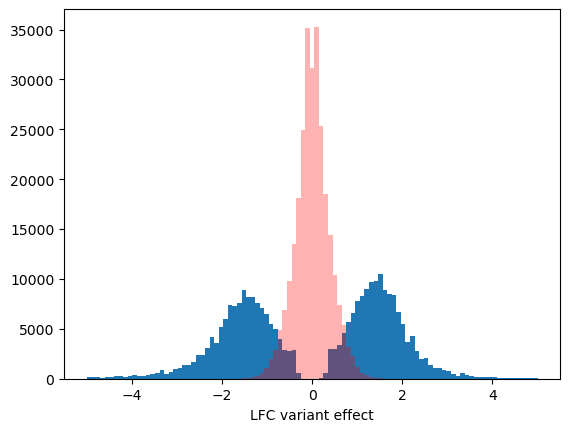

In [20]:
import matplotlib.pyplot as plt
bins = np.linspace(-5, 5, 100)
h = plt.hist(positives.logit_es, bins=bins)
h = plt.hist(negatives.logit_es, bins=bins, color="red", alpha=0.3)
plt.xlabel("LFC variant effect")

In [30]:
var_df

,#chr,start,end,ID,ref,alt,AAF,RAF
variant_id,,,,,,,,
chr1:804904:C:T,chr1,804903,804904,rs61770167,C,T,0.004093,0.995907
chr1:817186:G:A,chr1,817185,817186,rs3094315,G,A,0.706382,0.293323
chr1:817237:C:A,chr1,817236,817237,rs149886465,C,A,0.035081,0.964919
chr1:817341:A:G,chr1,817340,817341,rs3131972,A,G,0.665607,0.334393
chr1:817375:T:C,chr1,817374,817375,rs1417671147,T,C,0.000048,0.999952
...,...,...,...,...,...,...,...,...
chr9:138155803:G:A,chr9,138155802,138155803,rs147604762,G,A,0.207585,0.792391
chr9:138155904:T:G,chr9,138155903,138155904,rs9410084,T,G,0.713892,0.286020
chr9:138155977:G:T,chr9,138155976,138155977,rs12683077,G,T,0.136850,0.863150


In [17]:
indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')
indiv_id_mapping

,ln_number,ds_number,tc_number,core_annotation,extended_annotation,core_ontology_term,sample_type,system,subsystem,organ,...,total_cutcounts_file,cutcounts_tabix,SPOT1_score,SPOT3_score,total_fastq_reads,nuclear_reads,alignment_quality,nuclear_dup_rate,indiv_id,snps_file
sample_id,,,,,,,,,,,,,,,,,,,,,
AG10028,LN45952,DS58903,TC2653,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3182,0.074446,52520104,43150608,0.821602,0.090581,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10029,LN45951,DS58898,TC2652,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3060,0.057275,54654080,44625318,0.816505,0.097833,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10031,LN45947,DS58779,TC2652,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3236,0.084240,62032686,48761214,0.786057,0.121074,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10032,LN45945,DS58765,TC2650,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3407,0.092941,65021458,51644128,0.794263,0.117462,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10033,LN45944,DS58761,TC2649,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3458,0.099725,62713902,50214894,0.800698,0.109526,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AG70923,LN26979,DS28156,TC4770,Myeloid,Monocyte,CD14+ monocyte,Primary cells/tissues,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.2507,0.088885,21458764,14001510,0.652484,0.322671,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG72731,LN54316,DS70424,TC8000,Fetal life support,Fetal life support,Placenta,Primary cells/tissues,Reproductive,NaN,Placenta,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.5123,0.316107,205268193,168995390,0.823291,0.329474,INDIV_0433,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG4026,LN33516,DS40210,TC5870,Colon,Colon,Transverse colon,Primary cells/tissues,Digestive,NaN,Colon,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.2153,0.123919,217560462,110999900,0.510203,0.332484,INDIV_0015,/net/seq/data2/projects/sabramov/ENCODE4/dnase...


In [18]:
variants["indiv_id"] = (
    variants["sample_id"].map(indiv_id_mapping["indiv_id"]).fillna("").astype(str)
)

/tmp/slurm.8384754/ipykernel_4025004/4127241232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variants["indiv_id"] = (


In [20]:
variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id,variant_id,total_counts,indiv_id
23,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,0.499560,0.937686,0,-,0,14.564382,all,chr1:804904:C:T,35,INDIV_0120
65,chr1,817185,817186,rs3094315,G,A,23,13,AG80733,0.706382,...,0.754975,1.000000,0,-,0,9.451293,all,chr1:817186:G:A,36,INDIV_0287
66,chr1,817185,817186,rs3094315,G,A,26,29,AG80823,0.706382,...,0.706269,0.971396,0,-,0,9.795636,all,chr1:817186:G:A,55,INDIV_0314
69,chr1,817185,817186,rs3094315,G,A,33,24,AG70842,0.706382,...,0.872472,0.891271,0,-,0,9.818754,all,chr1:817186:G:A,57,INDIV_0010
71,chr1,817185,817186,rs3094315,G,A,43,36,AG80260,0.706382,...,0.459450,0.937870,0,-,0,9.996950,all,chr1:817186:G:A,79,INDIV_0051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48190720,chr9,138217445,138217446,rs11562371,C,T,19,21,AG80066,0.370349,...,0.874629,1.000000,0,-,0,15.569979,all,chr9:138217446:C:T,40,INDIV_0032
48190724,chr9,138217445,138217446,rs11562371,C,T,21,24,AG96533,0.370349,...,0.788662,1.000000,0,-,0,9.649918,all,chr9:138217446:C:T,45,INDIV_0138
48190725,chr9,138217445,138217446,rs11562371,C,T,22,29,AG80065,0.370349,...,0.401062,1.000000,0,-,0,17.580981,all,chr9:138217446:C:T,51,INDIV_0032
48190727,chr9,138217445,138217446,rs11562371,C,T,26,13,AG80357,0.370349,...,0.494174,1.000000,0,-,0,9.527468,all,chr9:138217446:C:T,39,INDIV_0070


In [38]:
# train_data = variants.merge(
#     ambiguous_df.assign(ambiguous=True),
#     on=["#chr", "start", "indiv_id"],
#     how="left"
# )
train_data = variants.merge(
    ambiguous_df.assign(ambiguous=True),
    on=["#chr", "start", "indiv_id"],
    how="left"
)


# True if ambiguous, NaN otherwise
num_ambiguous = train_data["ambiguous"].sum()
print(f"Removing {num_ambiguous} ambiguous variants")


Removing 122 ambiguous variants


In [39]:
train_data = train_data[train_data["ambiguous"].isna()]
train_data.drop(columns="ambiguous", inplace=True)

In [40]:
var_df = train_data.drop_duplicates('variant_id').set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]

In [41]:
var_df

,#chr,start,end,ID,ref,alt,AAF,RAF
variant_id,,,,,,,,
chr1:804904:C:T,chr1,804903,804904,rs61770167,C,T,0.004093,0.995907
chr1:817186:G:A,chr1,817185,817186,rs3094315,G,A,0.706382,0.293323
chr1:817237:C:A,chr1,817236,817237,rs149886465,C,A,0.035081,0.964919
chr1:817341:A:G,chr1,817340,817341,rs3131972,A,G,0.665607,0.334393
chr1:817375:T:C,chr1,817374,817375,rs1417671147,T,C,0.000048,0.999952
...,...,...,...,...,...,...,...,...
chr9:138155803:G:A,chr9,138155802,138155803,rs147604762,G,A,0.207585,0.792391
chr9:138155904:T:G,chr9,138155903,138155904,rs9410084,T,G,0.713892,0.286020
chr9:138155977:G:T,chr9,138155976,138155977,rs12683077,G,T,0.136850,0.863150


In [27]:
train_var_adata = ad.AnnData(X=None, var=var_df, obs=adata.obs)
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757924
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [28]:
row_idx = train_var_adata.obs_names.get_indexer(train_data["sample_id"])

# Map variant_id -> col index
col_idx = train_var_adata.var_names.get_indexer(train_data["variant_id"])

for column in tqdm(['ref_counts', 'total_counts', 'BAD', 'logit_es', 'FDR_sample']):
    data = sp.coo_matrix(
        (train_data[column], (row_idx, col_idx)),
        shape=train_var_adata.shape
    ).tocsr()
    train_var_adata.layers[column] = data


100%|██████████| 5/5 [00:00<00:00,  6.01it/s]


In [29]:
indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')
indiv_id_mapping

,ln_number,ds_number,tc_number,core_annotation,extended_annotation,core_ontology_term,sample_type,system,subsystem,organ,...,total_cutcounts_file,cutcounts_tabix,SPOT1_score,SPOT3_score,total_fastq_reads,nuclear_reads,alignment_quality,nuclear_dup_rate,indiv_id,snps_file
sample_id,,,,,,,,,,,,,,,,,,,,,
AG10028,LN45952,DS58903,TC2653,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3182,0.074446,52520104,43150608,0.821602,0.090581,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10029,LN45951,DS58898,TC2652,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3060,0.057275,54654080,44625318,0.816505,0.097833,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10031,LN45947,DS58779,TC2652,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3236,0.084240,62032686,48761214,0.786057,0.121074,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10032,LN45945,DS58765,TC2650,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3407,0.092941,65021458,51644128,0.794263,0.117462,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10033,LN45944,DS58761,TC2649,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3458,0.099725,62713902,50214894,0.800698,0.109526,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AG70923,LN26979,DS28156,TC4770,Myeloid,Monocyte,CD14+ monocyte,Primary cells/tissues,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.2507,0.088885,21458764,14001510,0.652484,0.322671,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG72731,LN54316,DS70424,TC8000,Fetal life support,Fetal life support,Placenta,Primary cells/tissues,Reproductive,NaN,Placenta,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.5123,0.316107,205268193,168995390,0.823291,0.329474,INDIV_0433,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG4026,LN33516,DS40210,TC5870,Colon,Colon,Transverse colon,Primary cells/tissues,Digestive,NaN,Colon,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.2153,0.123919,217560462,110999900,0.510203,0.332484,INDIV_0015,/net/seq/data2/projects/sabramov/ENCODE4/dnase...


In [30]:
indiv_id_mapping['indiv_id']

sample_id
AG10028           NaN
AG10029           NaN
AG10031    INDIV_0002
AG10032    INDIV_0002
AG10033    INDIV_0002
              ...    
AG70923           NaN
AG72731    INDIV_0433
AG4026     INDIV_0015
AG4009     INDIV_0018
AG80141    INDIV_0363
Name: indiv_id, Length: 3480, dtype: object

In [31]:
train_var_adata.obsm['indiv_id'] = train_var_adata.obs_names.map(indiv_id_mapping['indiv_id']).fillna('').to_numpy().astype(str)

In [32]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757924
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [33]:
sampled_val = pd.Series(train_var_adata.obs_names).sample(50).values
validation_chroms = ['chr9', 'chr22']

In [34]:
train_var_adata.uns['epoch_names'] = ['epoch_1']
train_var_adata.uns['n_epochs'] = 1
train_var_adata.obsm['motif_embeddings'] = adata.obsm['motif_embeddings'].loc[train_var_adata.obs_names]
train_var_adata.obsm['split_data'] = np.where(train_var_adata.obs_names.isin(sampled_val), 'val', 'train')
train_var_adata.varm['split_data'] = np.where(train_var_adata.var['#chr'].isin(validation_chroms), 'val', 'train')
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757924
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [35]:
for layer in list(train_var_adata.layers):
    train_var_adata.layers[f"{layer}.epoch_1"] = train_var_adata.layers[layer]
    del train_var_adata.layers[layer]

In [36]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757924
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [37]:
train_var_adata.write_h5ad('/net/seq/data2/projects/mbrannon/variant_train_adata_wfdr_noambig.h5ad')